In [1]:
# =============================================================
# CELLULE 1 — IMPORTS ET CONFIGURATION
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seed pour la reproductibilité
SEED = 42
np.random.seed(SEED)

# Style des graphiques
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"]      = 12

# Options d'affichage pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",    100)
pd.set_option("display.precision",   2)

print("✓ Environnement configuré avec succès.")

✓ Environnement configuré avec succès.


In [2]:
# =============================================================
# CELLULE 2 — CHARGEMENT DU DATASET BRUT
# =============================================================

df = pd.read_csv("../data/raw/diabetic_data.csv",
                 na_values="?",
                 low_memory=False)

# --- Copie de travail ---
# On ne touche jamais df (données brutes)
# Toutes les modifications se font sur df_clean
df_clean = df.copy()

# --- Dimensions avant nettoyage ---
print("=" * 45)
print("DATASET BRUT — AVANT NETTOYAGE")
print("=" * 45)
print(f"  Lignes   : {df.shape[0]:,}")
print(f"  Colonnes : {df.shape[1]}")
print("=" * 45)

DATASET BRUT — AVANT NETTOYAGE
  Lignes   : 101,766
  Colonnes : 50


In [3]:
# =============================================================
# CELLULE 3 — SUPPRESSION DES COLONNES INUTILES
# =============================================================

# NOTE : on NE supprime PAS encounter_id ni patient_nbr ici.
# Ils sont nécessaires au NB02 (déduplication chronologique + split
# stratifié par patient + assertions anti-leakage). Ils seront
# retirés des features au moment de définir X, dans le NB02.

colonnes_a_supprimer = {
    "weight"     : "97% de valeurs manquantes",
    "payer_code" : "52% de valeurs manquantes, peu utile cliniquement",
}

print("Colonnes supprimées :")
for col, raison in colonnes_a_supprimer.items():
    print(f"  - {col:<20} → {raison}")

# Suppression sur df_clean uniquement
df_clean = df_clean.drop(columns=list(colonnes_a_supprimer.keys()))

print(f"\nColonnes avant : {df.shape[1]}")
print(f"Colonnes après : {df_clean.shape[1]}")

Colonnes supprimées :
  - weight               → 97% de valeurs manquantes
  - payer_code           → 52% de valeurs manquantes, peu utile cliniquement

Colonnes avant : 50
Colonnes après : 48


In [4]:
# =============================================================
# CELLULE 4 — EXCLUSION DES PATIENTS DÉCÉDÉS OU EN HOSPICE
# =============================================================

# La colonne discharge_disposition_id indique la destination
# du patient à la sortie. Certains codes correspondent à un
# décès ou à un transfert en soins palliatifs (hospice) :
#   11 = décédé à l'hôpital
#   13 = hospice / domicile
#   14 = hospice / établissement médical
#   19 = décédé à domicile (soins palliatifs)
#   20 = décédé en établissement (soins palliatifs)
#   21 = décédé (lieu inconnu, soins palliatifs)
#
# Un patient décédé ne peut PAS être réadmis. Un patient en
# hospice (soins palliatifs) est en fin de vie : une réadmission
# n'a pas le même sens clinique et fausse la cible.
#
# CHOIX MÉTHODOLOGIQUE (aligné sur Strack et al. 2014 + spec projet) :
# on exclut décès ET hospice. Passer EXCLUDE_HOSPICE à False pour
# n'exclure que les décès (permet de comparer les deux approches).

EXCLUDE_HOSPICE = True # passe à False pour exclure les décès seulement

codes_deces   = [11, 19, 20, 21]   # décès
codes_hospice = [13, 14]           # soins palliatifs

codes_a_exclure = codes_deces + (codes_hospice if EXCLUDE_HOSPICE else [])
print(f"Codes exclus : {sorted(codes_a_exclure)}")

# --- Détail par code (traçabilité) ---
print("\nLignes concernées par code :")
for code in sorted(codes_a_exclure):
    n = (df_clean["discharge_disposition_id"] == code).sum()
    print(f"  code {code:>2} : {n:>6,} lignes")

# --- Nombre total de lignes concernées ---
nb_exclus = df_clean[
    df_clean["discharge_disposition_id"].isin(codes_a_exclure)
].shape[0]
print(f"\nTotal à exclure : {nb_exclus:,} lignes")

# --- Suppression ---
df_clean = df_clean[
    ~df_clean["discharge_disposition_id"].isin(codes_a_exclure)
]

# --- Vérification ---
print(f"\nLignes avant : {df.shape[0]:,}")
print(f"Lignes après : {df_clean.shape[0]:,}")
print(f"Lignes supprimées : {df.shape[0] - df_clean.shape[0]:,}")

Codes exclus : [11, 13, 14, 19, 20, 21]

Lignes concernées par code :
  code 11 :  1,642 lignes
  code 13 :    399 lignes
  code 14 :    372 lignes
  code 19 :      8 lignes
  code 20 :      2 lignes
  code 21 :      0 lignes

Total à exclure : 2,423 lignes

Lignes avant : 101,766
Lignes après : 99,343
Lignes supprimées : 2,423


In [5]:
# =============================================================
# CELLULE 5 — NETTOYAGE DE gender
# =============================================================

# gender contient quelques lignes "Unknown/Invalid".
# On les supprime (négligeable : ~3 lignes sur ~70k).
# → Placé AVANT la déduplication pour ne pas retenir par
#   erreur un séjour invalide comme "premier séjour".

nb_avant = len(df_clean)
df_clean = df_clean[df_clean["gender"] != "Unknown/Invalid"]
nb_apres = len(df_clean)

print(f"Lignes supprimées (gender inconnu) : {nb_avant - nb_apres}")
print(f"Lignes restantes : {nb_apres:,}")

print("\nDistribution gender :")
print(df_clean["gender"].value_counts())

Lignes supprimées (gender inconnu) : 3
Lignes restantes : 99,340

Distribution gender :
gender
Female    53454
Male      45886
Name: count, dtype: int64


In [6]:
# =============================================================
# CELLULE 6 — GESTION DES PATIENTS MULTI-SÉJOURS
# =============================================================

# Problème (DATA LEAKAGE) : un même patient peut apparaître
# plusieurs fois. S'il est à la fois dans le train et le test,
# le modèle "triche". → On ne garde qu'UN séjour par patient.

# Choix : le PREMIER séjour chronologique. Les encounter_id sont
# croissants dans le temps → on trie par encounter_id puis on
# garde la 1re occurrence de chaque patient_nbr.

# --- Avant ---
nb_avant          = len(df_clean)
nb_patients_avant = df_clean["patient_nbr"].nunique()

print("=" * 45)
print("AVANT")
print("=" * 45)
print(f"  Séjours  : {nb_avant:,}")
print(f"  Patients : {nb_patients_avant:,}")

# --- Déduplication chronologique ---
df_clean = (
    df_clean.sort_values("encounter_id")
            .drop_duplicates(subset="patient_nbr", keep="first")
            .reset_index(drop=True)
)

# --- Après ---
nb_apres          = len(df_clean)
nb_patients_apres = df_clean["patient_nbr"].nunique()

print("\n" + "=" * 45)
print("APRÈS")
print("=" * 45)
print(f"  Séjours  : {nb_apres:,}")
print(f"  Patients : {nb_patients_apres:,}")
print(f"\n  Lignes supprimées : {nb_avant - nb_apres:,}")

# --- Assertion anti-leakage ---
# NOTE : on NE supprime PAS patient_nbr ici. Il reste dans
# data_clean.csv pour permettre le split stratifié par patient
# et les contrôles du NB02.
assert df_clean["patient_nbr"].is_unique, "❌ Doublons patients restants !"
print("\n✓ Un seul séjour par patient. patient_nbr conservé pour le NB02.")

AVANT
  Séjours  : 99,340
  Patients : 69,987

APRÈS
  Séjours  : 69,987
  Patients : 69,987

  Lignes supprimées : 29,353

✓ Un seul séjour par patient. patient_nbr conservé pour le NB02.


In [7]:
# =============================================================
# CELLULE 7 — CONSTRUCTION DE LA VARIABLE CIBLE BINAIRE
# =============================================================

# La variable originale "readmitted" a 3 valeurs :
#   "<30" = réadmis en moins de 30 jours → 1 (cas positif)
#   ">30" = réadmis après 30 jours       → 0 (cas négatif)
#   "NO"  = jamais réadmis               → 0 (cas négatif)

# Création de la variable binaire.
# On GARDE la colonne 'readmitted' brute pour traçabilité ;
# elle sera retirée des features au NB02 (avec les identifiants).
df_clean["readmitted_binary"] = (df_clean["readmitted"] == "<30").astype(int)

# --- Vérification ---
counts = df_clean["readmitted_binary"].value_counts()
total  = len(df_clean)

print("=" * 45)
print("VARIABLE CIBLE BINAIRE")
print("=" * 45)
print(f"  Classe 0 (non réadmis) : {counts[0]:>6,}  ({counts[0]/total*100:.1f}%)")
print(f"  Classe 1 (réadmis <30) : {counts[1]:>6,}  ({counts[1]/total*100:.1f}%)")
print("=" * 45)

# Contrôle de cohérence
assert set(df_clean["readmitted_binary"].unique()) <= {0, 1}

VARIABLE CIBLE BINAIRE
  Classe 0 (non réadmis) : 63,702  (91.0%)
  Classe 1 (réadmis <30) :  6,285  (9.0%)


In [8]:
# =============================================================
# CELLULE 8 — CONTRÔLE ANTI-LEAKAGE (proxy de la cible)
# =============================================================

# Vérif : aucune modalité de discharge_disposition_id ne doit
# "prédire" trivialement la cible (proxy direct = leakage).

check = (
    df_clean.groupby("discharge_disposition_id")["readmitted_binary"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "taux_readmit", "count": "n"})
            .sort_values("taux_readmit", ascending=False)
)
print("Taux de réadmission par discharge_disposition_id :")
display(check.head(8))

suspects = check[(check["n"] >= 100) &
                 ((check["taux_readmit"] > 0.9) | (check["taux_readmit"] < 0.001))]
if len(suspects):
    print("\n⚠️ Modalités suspectes (proxy potentiel) :")
    display(suspects)
else:
    print("\n✓ Aucune modalité ne constitue un proxy direct de la cible.")

Taux de réadmission par discharge_disposition_id :


,taux_readmit,n
discharge_disposition_id,,
12,0.50,2
15,0.45,40
28,0.36,90
22,0.26,1410
9,0.22,9
5,0.21,913
2,0.14,1541
3,0.13,8790



✓ Aucune modalité ne constitue un proxy direct de la cible.


In [9]:
# =============================================================
# CELLULE 9 — DÉTAIL DE LA PERTE DE LIGNES
# =============================================================

print("Décès / hospice exclus :")
codes_deces_hospice = [11, 13, 14, 19, 20, 21]
nb_exclus = df[df["discharge_disposition_id"].isin(codes_deces_hospice)].shape[0]
print(f"  {nb_exclus:,}")

print("\nSéjours supprimés (multi-séjours) :")
nb_multi = df.shape[0] - df.drop_duplicates(subset="patient_nbr").shape[0]
print(f"  {nb_multi:,}")

Décès / hospice exclus :
  2,423

Séjours supprimés (multi-séjours) :
  30,248


In [10]:
# =============================================================
# CELLULE 10 — VÉRIFICATION FINALE
# =============================================================

print("=" * 50)
print("BILAN DU NETTOYAGE")
print("=" * 50)

# --- Dimensions ---
print(f"\n  Lignes avant   : {df.shape[0]:,}")
print(f"  Lignes après   : {df_clean.shape[0]:,}")
print(f"  Lignes perdues : {df.shape[0] - df_clean.shape[0]:,}")

print(f"\n  Colonnes avant : {df.shape[1]}")
print(f"  Colonnes après : {df_clean.shape[1]}")

# --- Valeurs manquantes ---
# NOTE : c'est NORMAL qu'il reste des NaN ici. L'imputation est
# faite au NB03, fit sur le TRAIN uniquement (anti-leakage).
print("\n" + "=" * 50)
print("VALEURS MANQUANTES RESTANTES (gérées au NB03)")
print("=" * 50)
manquantes = df_clean.isnull().sum()
manquantes = manquantes[manquantes > 0].sort_values(ascending=False)

if len(manquantes) == 0:
    print("  Aucune valeur manquante.")
else:
    for col, val in manquantes.items():
        pct = val / len(df_clean) * 100
        print(f"  {col:<25} {val:>6,}  ({pct:.1f}%)")

# --- Distribution de la cible ---
print("\n" + "=" * 50)
print("DISTRIBUTION DE LA VARIABLE CIBLE")
print("=" * 50)
counts = df_clean["readmitted_binary"].value_counts()
total  = len(df_clean)
print(f"  Classe 0 (non réadmis) : {counts[0]:>6,}  ({counts[0]/total*100:.1f}%)")
print(f"  Classe 1 (réadmis <30) : {counts[1]:>6,}  ({counts[1]/total*100:.1f}%)")

# --- Aperçu final ---
print("\n" + "=" * 50)
print("APERÇU DU DATASET NETTOYÉ")
print("=" * 50)
display(df_clean.head())

BILAN DU NETTOYAGE

  Lignes avant   : 101,766
  Lignes après   : 69,987
  Lignes perdues : 31,779

  Colonnes avant : 50
  Colonnes après : 49

VALEURS MANQUANTES RESTANTES (gérées au NB03)
  max_glu_serum             66,638  (95.2%)
  A1Cresult                 57,141  (81.6%)
  medical_specialty         33,652  (48.1%)
  race                       1,917  (2.7%)
  diag_3                     1,224  (1.7%)
  diag_2                       293  (0.4%)
  diag_1                        10  (0.0%)

DISTRIBUTION DE LA VARIABLE CIBLE
  Classe 0 (non réadmis) : 63,702  (91.0%)
  Classe 1 (réadmis <30) :  6,285  (9.0%)

APERÇU DU DATASET NETTOYÉ


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_binary
0,12522,48330783,Caucasian,Female,[80-90),2,1,4,13,NaN,68,2,28,0,0,0,398,427,38,8,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0
1,15738,63555939,Caucasian,Female,[90-100),3,3,4,12,InternalMedicine,33,3,18,0,0,0,434,198,486,8,NaN,NaN,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0
2,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0
3,28236,89869032,AfricanAmerican,Female,[40-50),1,1,7,9,NaN,47,2,17,0,0,0,250.7,403,996,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30,0
4,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,NaN,31,6,16,0,0,0,414,411,250,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30,0


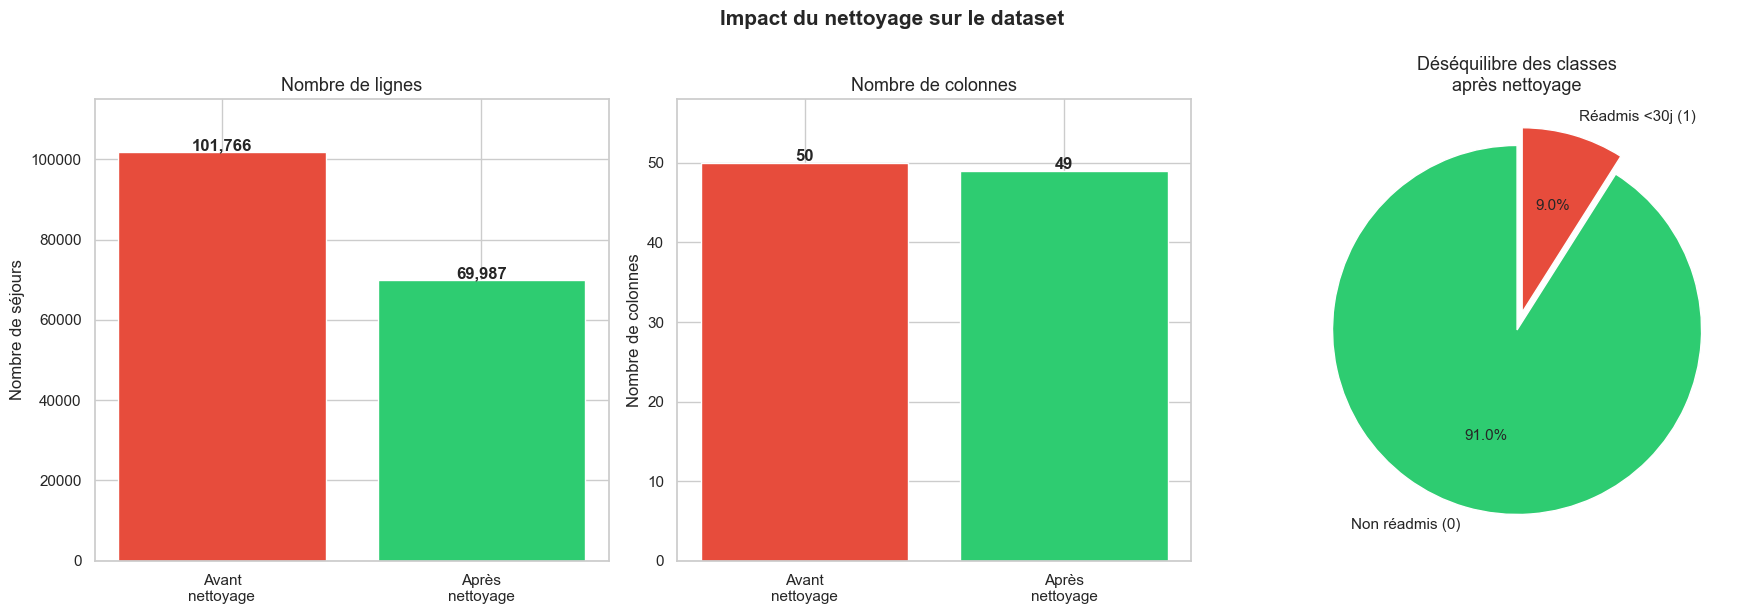

In [11]:
# =============================================================
# CELLULE 11 — VISUALISATION DE L'IMPACT DU NETTOYAGE
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Graphique 1 : Lignes avant / après ---
labels   = ["Avant\nnettoyage", "Après\nnettoyage"]
valeurs  = [df.shape[0], df_clean.shape[0]]
couleurs = ["#E74C3C", "#2ECC71"]

bars = axes[0].bar(labels, valeurs, color=couleurs, edgecolor="white")
for bar, val in zip(bars, valeurs):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 500,
                 f"{val:,}", ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Nombre de lignes", fontsize=13)
axes[0].set_ylabel("Nombre de séjours")
axes[0].set_ylim(0, 115000)

# --- Graphique 2 : Colonnes avant / après ---
valeurs_col = [df.shape[1], df_clean.shape[1]]
bars = axes[1].bar(labels, valeurs_col, color=couleurs, edgecolor="white")
for bar, val in zip(bars, valeurs_col):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{val}", ha="center", fontsize=12, fontweight="bold")
axes[1].set_title("Nombre de colonnes", fontsize=13)
axes[1].set_ylabel("Nombre de colonnes")
axes[1].set_ylim(0, 58)

# --- Graphique 3 : Déséquilibre des classes ---
counts = df_clean["readmitted_binary"].value_counts()
axes[2].pie([counts[0], counts[1]],
            labels=["Non réadmis (0)", "Réadmis <30j (1)"],
            colors=["#2ECC71", "#E74C3C"],
            autopct="%1.1f%%",
            explode=(0, 0.1),
            startangle=90,
            textprops={"fontsize": 11})
axes[2].set_title("Déséquilibre des classes\naprès nettoyage", fontsize=13)

plt.suptitle("Impact du nettoyage sur le dataset",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# =============================================================
# CELLULE 12 — SAUVEGARDE DU DATASET NETTOYÉ
# =============================================================

# Ce fichier alimente tous les notebooks suivants.
# Il CONSERVE volontairement : encounter_id, patient_nbr,
# readmitted (brute) et les NaN → tout est traité au NB02.

chemin = "../data/processed/data_clean.csv"
df_clean.to_csv(chemin, index=False)

print("✓ Dataset nettoyé sauvegardé avec succès.")
print(f"  Chemin   : {chemin}")
print(f"  Lignes   : {df_clean.shape[0]:,}")
print(f"  Colonnes : {df_clean.shape[1]}")
print(f"\n  Colonnes conservées pour le NB03 :")
print(f"    - encounter_id, patient_nbr (split + anti-leakage)")
print(f"    - readmitted (brute, traçabilité) + readmitted_binary (cible)")
print(f"    - NaN non imputés (imputation fit sur train au NB03)")

✓ Dataset nettoyé sauvegardé avec succès.
  Chemin   : ../data/processed/data_clean.csv
  Lignes   : 69,987
  Colonnes : 49

  Colonnes conservées pour le NB03 :
    - encounter_id, patient_nbr (split + anti-leakage)
    - readmitted (brute, traçabilité) + readmitted_binary (cible)
    - NaN non imputés (imputation fit sur train au NB03)


# NB02 — Nettoyage structurel

**Projet :** Prédiction de la réhospitalisation précoce (< 30 jours) des patients diabétiques
**Dataset :** Diabetes 130-US Hospitals for Years 1999–2008 (Kaggle / UCI)

---

## Objectif
Appliquer les opérations **structurelles** sur les données brutes, **avant** tout
split ou apprentissage. Ces opérations sont déterministes et ne présentent aucun
risque de data leakage.

## Opérations réalisées
1. **Suppression de colonnes** : `weight` (97% manquant) et `payer_code` (52% manquant, faible pertinence clinique)
2. **Exclusion décès / hospice** : `discharge_disposition_id` ∈ {11, 13, 14, 19, 20, 21}
   → un patient décédé ne peut pas être réadmis ; un patient en soins palliatifs
   fausse la cible (aligné sur Strack et al. 2014)
3. **Déduplication par patient** : on garde le **premier séjour chronologique**
   (plus petit `encounter_id`) de chaque `patient_nbr`
   → évite le leakage inter-patient (risque critique n°1)
4. **Binarisation de la cible** : `readmitted` "<30" → 1, sinon → 0

## Ce que ce notebook NE fait PAS (volontairement)
- ❌ Aucune imputation des valeurs manquantes → reportée au NB03 (fit sur train)
- ❌ Aucune suppression d'identifiant → `patient_nbr`, `encounter_id` conservés pour le split
- ❌ La cible brute `readmitted` est conservée pour la traçabilité

## Entrée / Sortie
- **Entrée** : `data/raw/diabetic_data.csv`
- **Sortie** : `data/processed/data_clean.csv` (~69 987 lignes, NaN conservés)

## Note méthodologique
Le compte final (~69 987 lignes) correspond aux 69 984 de Strack et al. (2014),
ce qui valide la conformité du nettoyage.